# Quick Look EDA (Stroke Prevention Dataset)

**Author:** Emmanuel Darkwa  
**NetID:** edark3  
**Purpose:** A fast, standardized EDA walkthrough of the shared stroke dataset.  
This notebook is a reference example for the team (not a submission template).

**What this notebook covers**
- Dataset shape + schema (dtypes)
- Target validation + imbalance
- Missingness overview
- Basic distributions (numeric + categorical)
- Feature vs target checks (signal)
- Light preprocessing experiments (flags, bins, simple imputes)
- Deliverable: clear takeaways + recommendations for Week 3


## 1. Setup & Data Loading

This section imports required libraries and loads the shared dataset using a relative path.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "raw" / "stroke_data.csv"
df = pd.read_csv(DATA_PATH)

df.head()




,stroke,gender,age,Race,Marital status,alcohol,smoke,sleep disorder,Health Insurance,General health condition,...,energy,protein,Carbohydrate,Dietary fiber,Total fat,Total saturated fatty acids,Total monounsaturated fatty acids,Total polyunsaturated fatty acids,Potassium,Sodium
0,0,2,2,5,1,0,0,2,2,3,...,1598,62.78,192.19,10.0,65.64,25.112,24.090,8.543,2887,2969
1,0,2,2,1,1,0,0,1,2,3,...,1547,45.35,256.02,17.0,42.56,13.423,15.389,10.613,2058,2091
2,1,1,2,3,1,1,1,2,1,3,...,2466,81.56,254.49,13.0,103.32,43.295,36.727,15.366,3117,5233
3,0,2,3,3,1,1,1,2,1,4,...,1605,70.99,143.37,10.0,81.60,24.527,30.567,18.174,1766,3706
4,0,1,1,4,1,0,0,2,1,2,...,1818,74.75,229.45,14.2,67.49,26.030,24.837,10.533,1842,2461


In [ ]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nDtypes:\n", df.dtypes)


Shape: (4603, 36)

Columns: ['stroke', 'gender', 'age', 'Race', 'Marital status', 'alcohol ', 'smoke', 'sleep disorder', 'Health Insurance', 'General health condition', 'depression', 'sleep time', 'diabetes', 'hypertension', 'high cholesterol', 'Minutes sedentary activity', 'Coronary Heart Disease', 'Body Mass Index', 'Waist Circumference', 'Systolic blood pressure', 'Diastolic blood pressure', 'High-density lipoprotein', 'Triglyceride', 'Low-density lipoprotein', 'Fasting Glucose', 'Glycohemoglobin', 'energy', 'protein', 'Carbohydrate', 'Dietary fiber', 'Total fat', 'Total saturated fatty acids', 'Total monounsaturated fatty acids', 'Total polyunsaturated fatty acids', 'Potassium', 'Sodium']

Dtypes:
 stroke                                 int64
gender                                 int64
age                                    int64
Race                                   int64
Marital status                         int64
alcohol                                int64
smoke             

## 1) Target validation (stroke)
We check:
- Does the target column exist?
- Is it binary?
- How imbalanced is it?


In [16]:
TARGET = "stroke"
assert TARGET in df.columns, f"Missing target column: {TARGET}"

counts = df[TARGET].value_counts(dropna=False)
pct = df[TARGET].value_counts(normalize=True, dropna=False).round(4)

display(pd.DataFrame({"count": counts, "pct": pct}))


,count,pct
stroke,,
0,4241,0.9214
1,362,0.0786


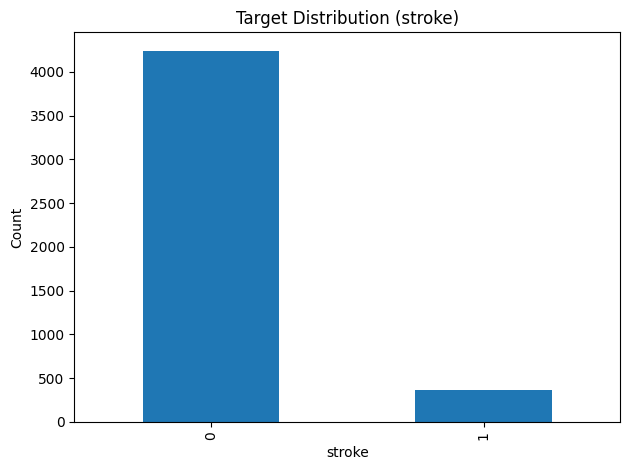

In [17]:
plt.figure()
counts.plot(kind="bar")
plt.title("Target Distribution (stroke)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 2) Missingness overview
Goal: identify which columns have missing values and decide:
- drop?
- impute?
- add missingness flag?


In [18]:
missing_count = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)

missing = pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct})
missing = missing.sort_values("missing_pct", ascending=False)

display(missing.head(25))


,missing_count,missing_pct
stroke,0,0.0
gender,0,0.0
Diastolic blood pressure,0,0.0
High-density lipoprotein,0,0.0
Triglyceride,0,0.0
Low-density lipoprotein,0,0.0
Fasting Glucose,0,0.0
Glycohemoglobin,0,0.0
energy,0,0.0
protein,0,0.0


IndexError: index 0 is out of bounds for axis 0 with size 0

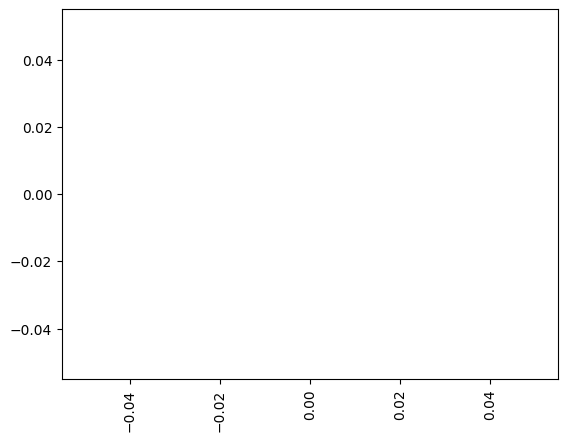

In [19]:
top_missing = missing[missing["missing_pct"] > 0].head(15)

plt.figure()
top_missing["missing_pct"].plot(kind="bar")
plt.title("Top Missingness (%)")
plt.ylabel("Missing %")
plt.tight_layout()
plt.show()


## 3) Duplicate rows + basic value checks
We quickly check duplicates and suspicious ranges.


In [20]:
dups = df.duplicated().sum()
print("Duplicate rows:", dups)


Duplicate rows: 0


In [ ]:
# (Quick numeric ranges + outliers-ish)
numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
summary = df[numeric_cols].describe().T
summary["range"] = summary["max"] - summary["min"]
display(summary.sort_values("range", ascending=False).head(15))


,count,mean,std,min,25%,50%,75%,max,range
Sodium,4603.0,3349.222029,1743.578856,7.000,2154.500000,3027.000000,4178.000000,20183.000,20176.000
Potassium,4603.0,2572.357593,1226.695804,0.000,1732.000000,2386.000000,3218.500000,14812.000,14812.000
energy,4603.0,2010.275690,935.655087,0.000,1365.000000,1856.000000,2467.000000,13687.000,13687.000
Carbohydrate,4603.0,240.295342,118.861157,0.000,160.380000,221.170000,296.295000,1815.020,1815.020
Minutes sedentary activity,4603.0,376.649794,201.396635,0.000,240.000000,360.000000,480.000000,1200.000,1200.000
Total fat,4603.0,77.773109,44.597697,0.000,46.285000,69.510000,99.320000,553.790,553.790
protein,4603.0,77.493461,40.007600,0.000,50.240000,70.260000,95.455000,387.370,387.370
Total monounsaturated fatty acids,4603.0,27.892491,16.936738,0.000,16.138000,24.344000,35.819000,221.673,221.673
Total saturated fatty acids,4603.0,25.084604,15.794243,0.000,14.148000,21.917000,32.332000,205.673,205.673
Systolic blood pressure,4603.0,132.946774,19.924444,66.000,120.000000,130.000000,144.000000,238.000,172.000


## 4) Distributions (numeric + categorical)
We inspect a few key features that often matter for stroke risk.

In [22]:
key_numeric = [c for c in ["age", "avg_glucose_level", "bmi"] if c in df.columns]
key_categorical = [c for c in ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"] if c in df.columns]

print("Key numeric:", key_numeric)
print("Key categorical:", key_categorical)


Key numeric: ['age']
Key categorical: ['gender']
